Code

{1: <saxs_analysis2.SAXSExperiment object at 0x000001E769A7B620>, 2: <saxs_analysis2.SAXSExperiment object at 0x000001E769AE1BD0>, 3: <saxs_analysis2.SAXSExperiment object at 0x000001E769AE2710>, 4: <saxs_analysis2.SAXSExperiment object at 0x000001E769ABEFD0>, 5: <saxs_analysis2.SAXSExperiment object at 0x000001E769ABF490>, 6: <saxs_analysis2.SAXSExperiment object at 0x000001E769B544D0>, 7: <saxs_analysis2.SAXSExperiment object at 0x000001E769ACBBD0>, 8: <saxs_analysis2.SAXSExperiment object at 0x000001E769BF8050>, 9: <saxs_analysis2.SAXSExperiment object at 0x000001E769B4F150>, 10: <saxs_analysis2.SAXSExperiment object at 0x000001E769B4F550>}


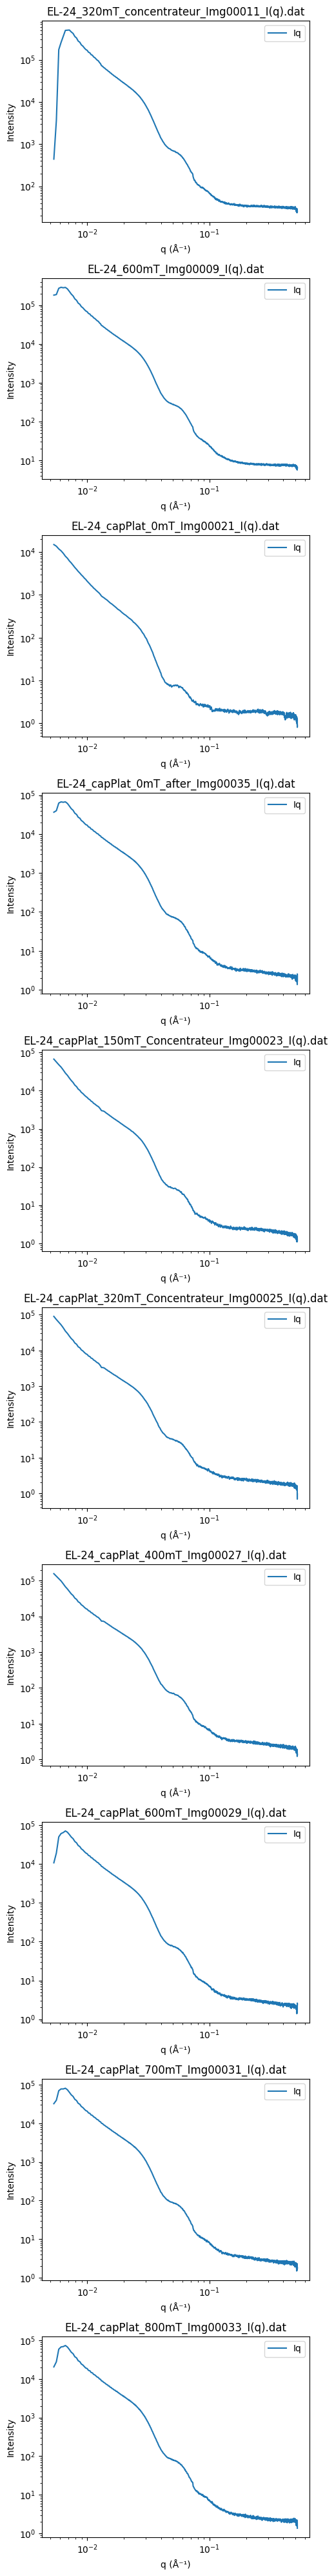

In [1]:
# méthode de tri séquentiel 
import os
from saxs_analysis2 import *

dir_path = r'\\netapp1\commperso\LPCNO\NCO\Data\Lisa Bacchin\20251208_LPCNO_Run8'
#dir_path = './Run_7'
sample_name = 'EmmaL'
type = 'radial_profiles'
#type = 'radial_profiles'
#type = 'integrations'

'''path = os.path.join(dir_path, sample_name, 'integrations')
print("Chemin complet :", path)
print("Existe :", os.path.isdir(path))
print("Accès lecture :", os.access(path, os.R_OK))

try:
    print("Contenu :", os.listdir(path))
except Exception as e:
    print("Erreur listdir :", e)'''

# Création du batch sans fonction de tri basée sur le nom
batch = SAXSBatch(
    dir_path=dir_path,
    sample_name=sample_name,
    type = type,
    file_patern='*',#ou '*.dat' si besoin
    sort_key=None  # pas besoin ici
)


batch.loadseq()
print(batch.experiments)
batch.plot( subplot=True, curves=(['Iq'],),  plot_type=('loglog'), legend=(True,))

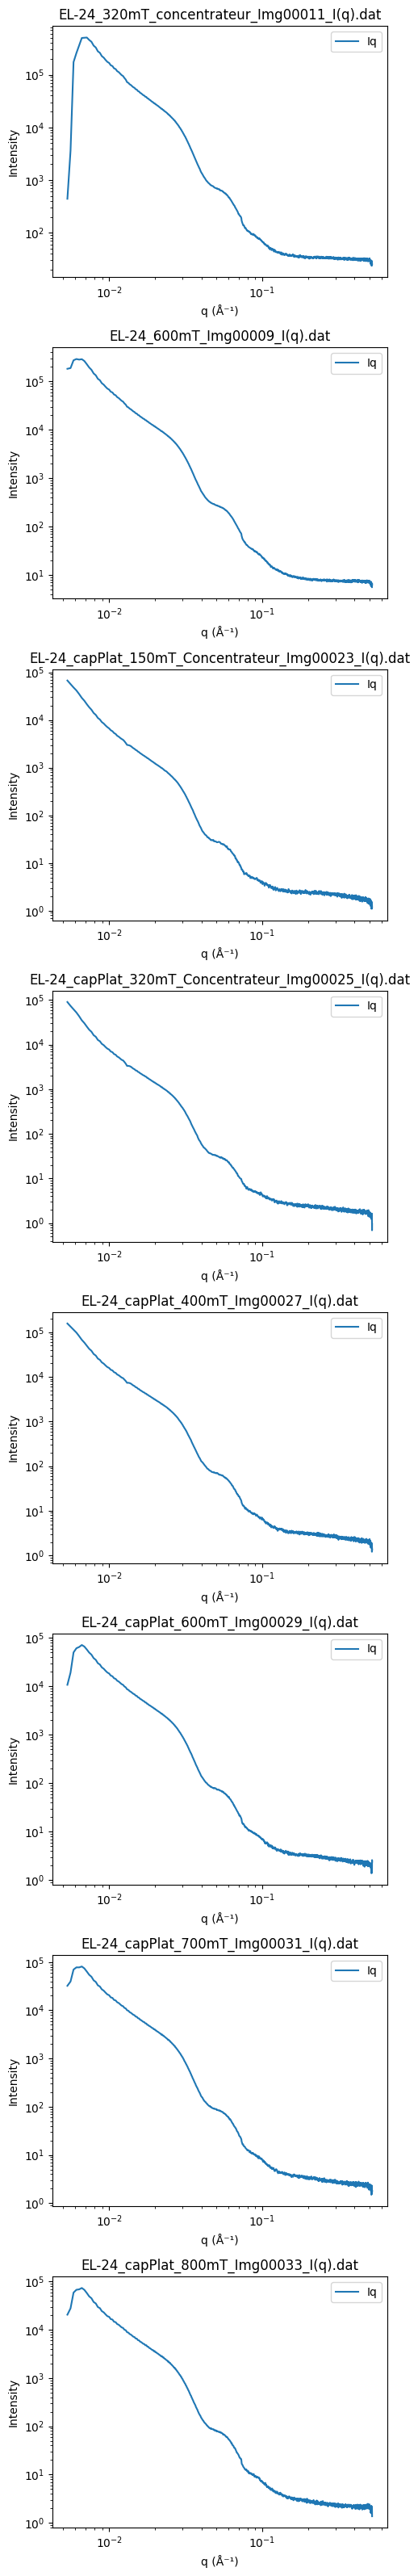

In [2]:
import re

#batch.filter(lambda i, k, v: -10 <= int(re.search(r'az=(-?\d+)°', v.name).group(1)) <= 10)
#batch.filter(lambda i, k, v: abs(int(re.search(r'az=(-?\d+)°', v.name).group(1))) > 10)
batch.filter(lambda i, k, v: "EL-24_capPlat_0mT" not in v.name)
batch.plot( subplot=True, curves=(['Iq'],),  plot_type=('loglog'), legend=(True,))

On calcule un ordre pour chaque exp


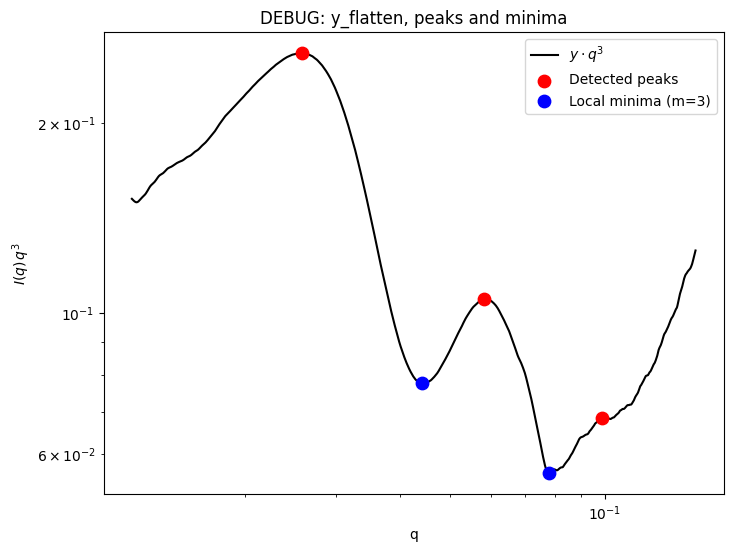

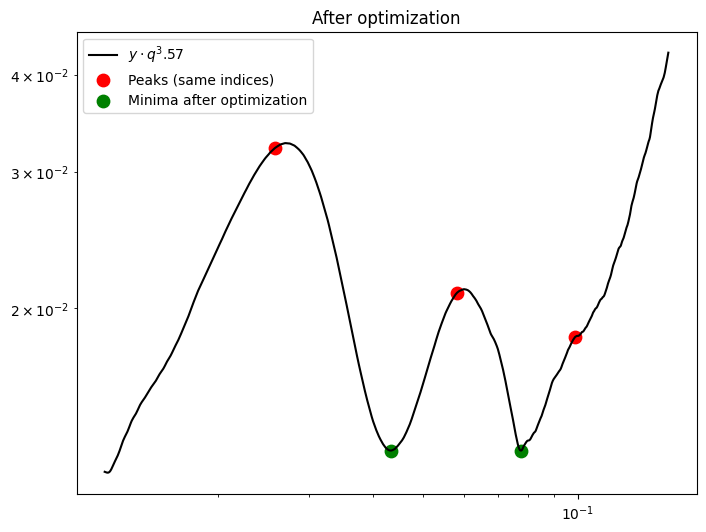

EL-24_320mT_concentrateur_Img00011_I(q).dat | order=None | Imin=None


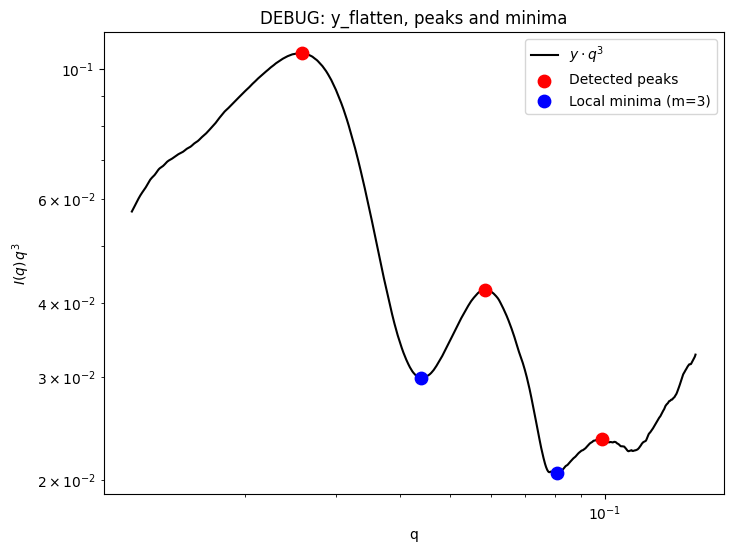

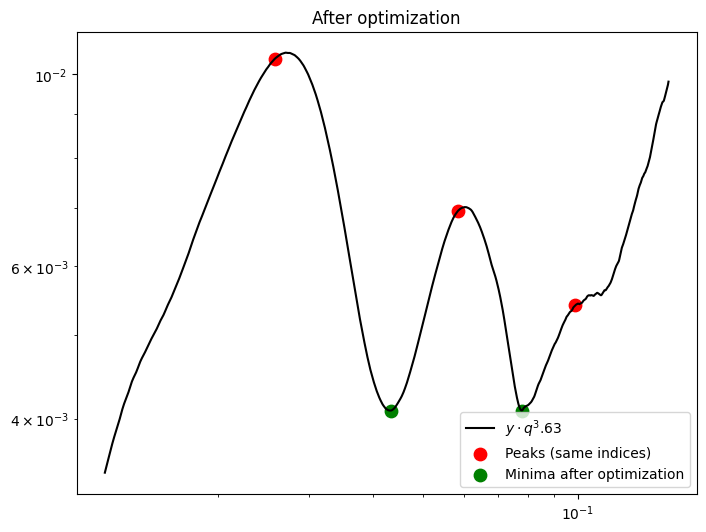

EL-24_600mT_Img00009_I(q).dat | order=None | Imin=None


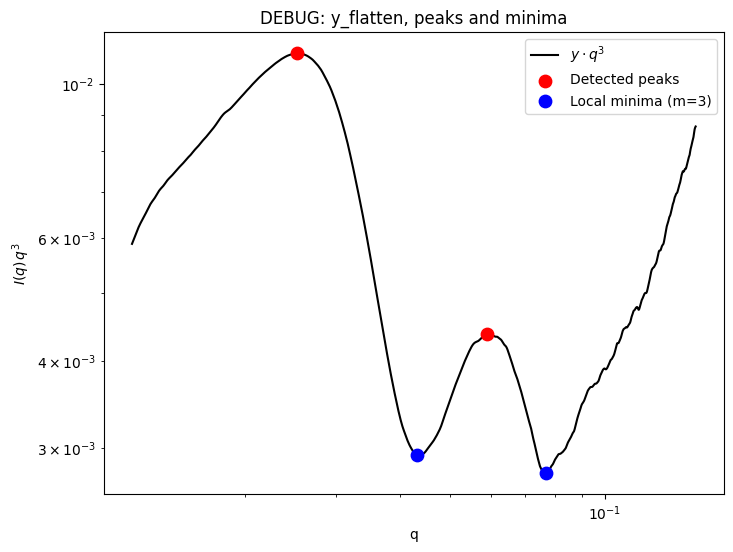

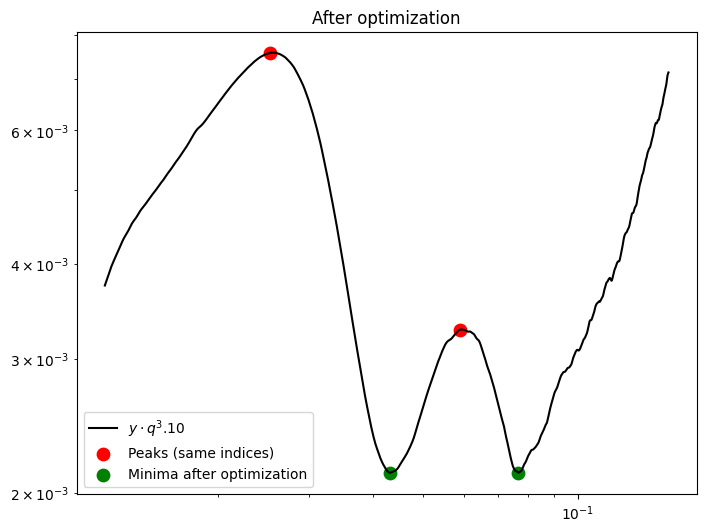

EL-24_capPlat_150mT_Concentrateur_Img00023_I(q).dat | order=None | Imin=None


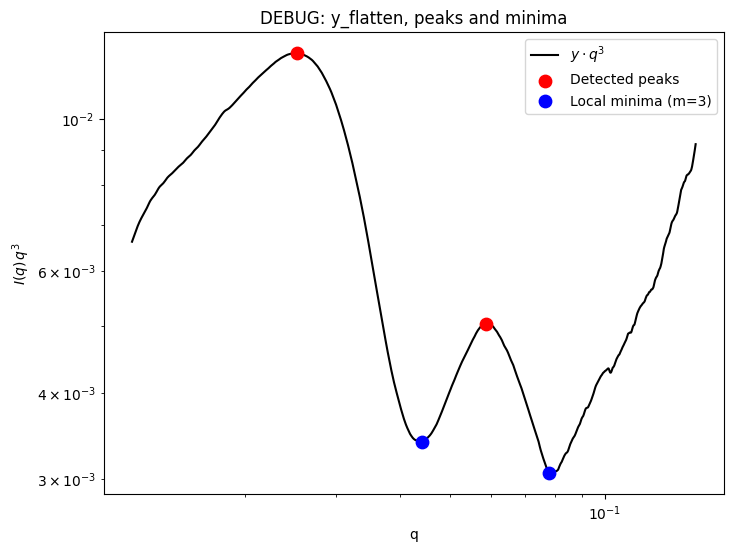

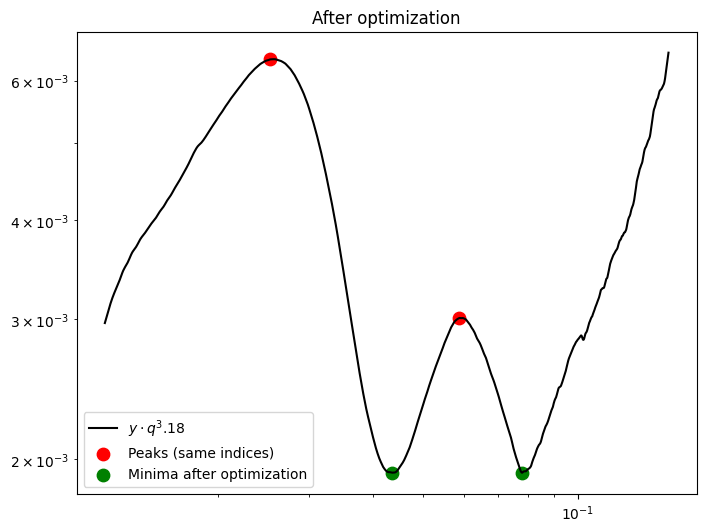

EL-24_capPlat_320mT_Concentrateur_Img00025_I(q).dat | order=None | Imin=None


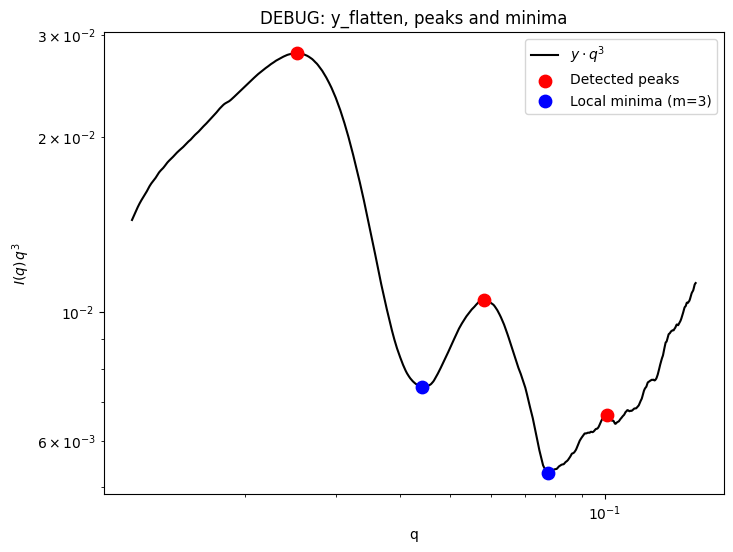

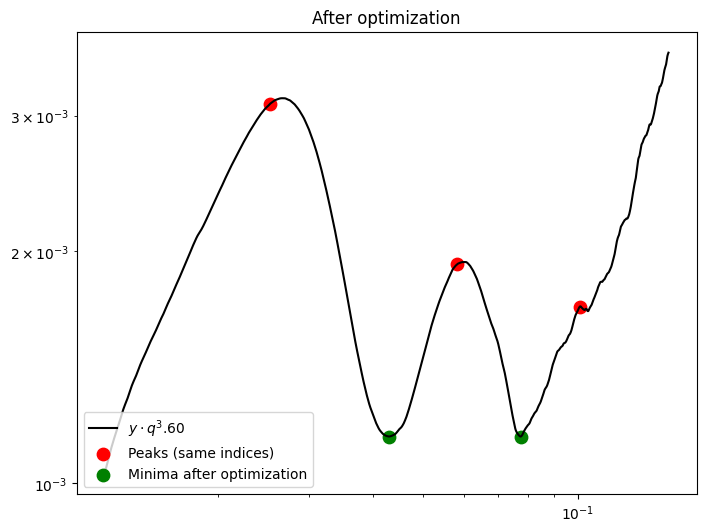

EL-24_capPlat_400mT_Img00027_I(q).dat | order=None | Imin=None


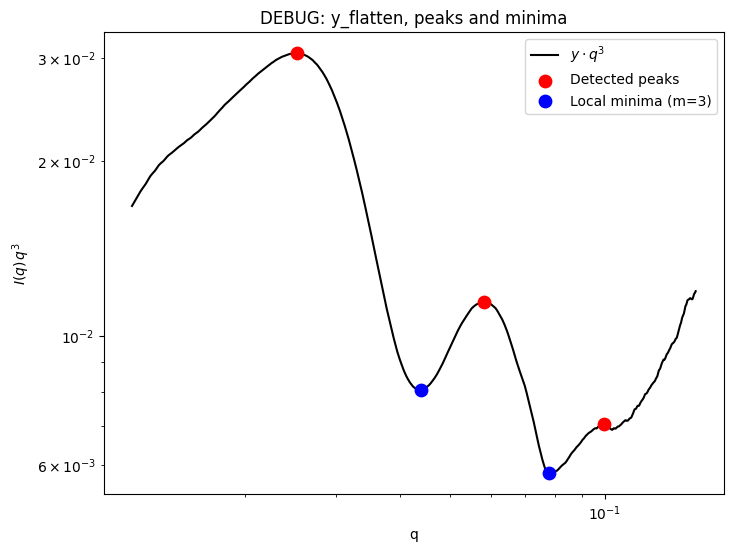

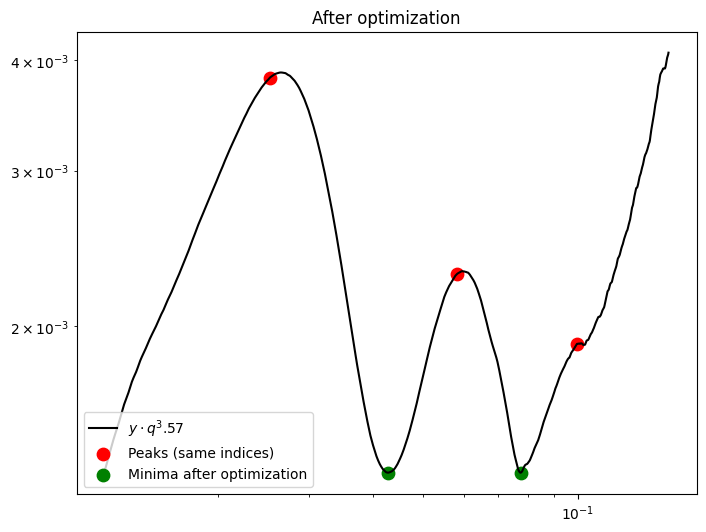

EL-24_capPlat_600mT_Img00029_I(q).dat | order=None | Imin=None


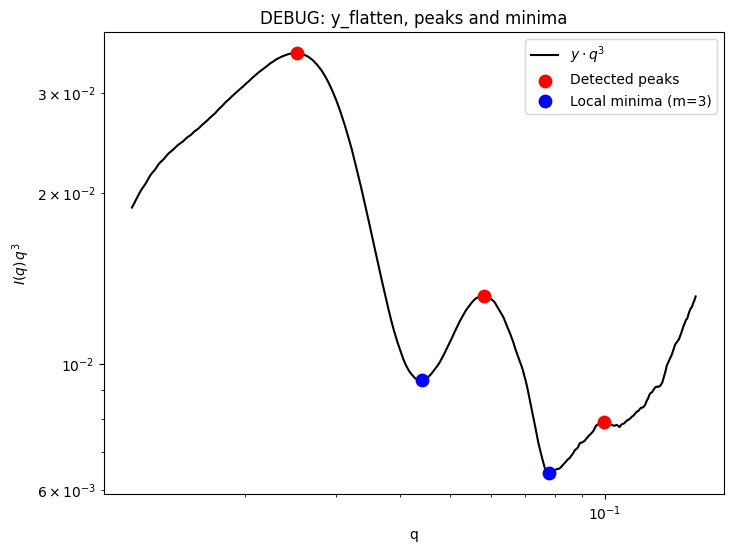

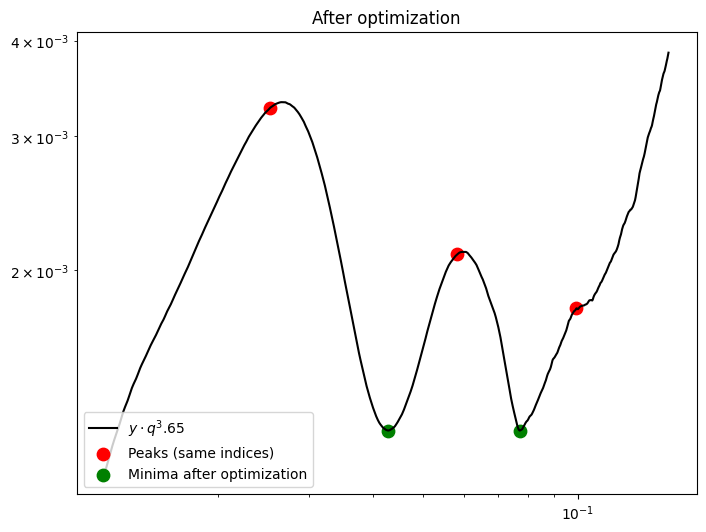

EL-24_capPlat_700mT_Img00031_I(q).dat | order=None | Imin=None


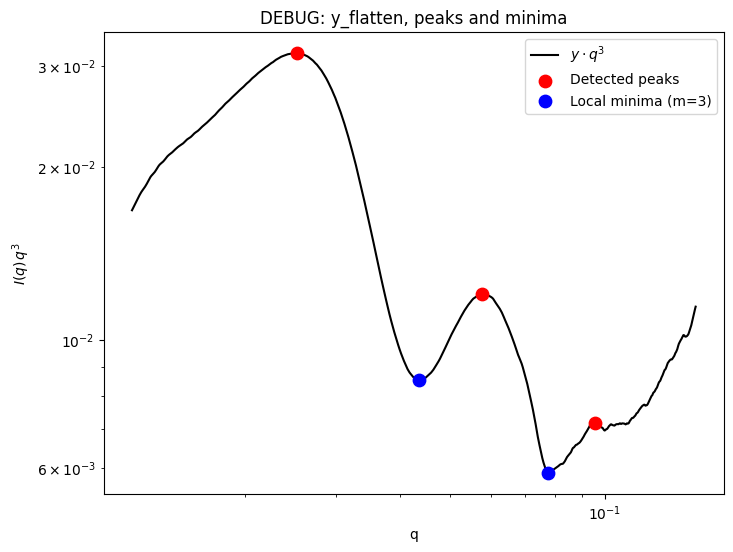

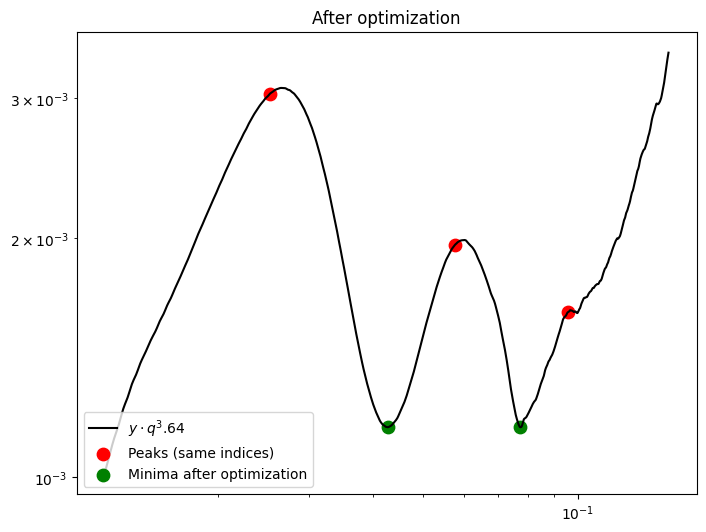

EL-24_capPlat_800mT_Img00033_I(q).dat | order=None | Imin=None


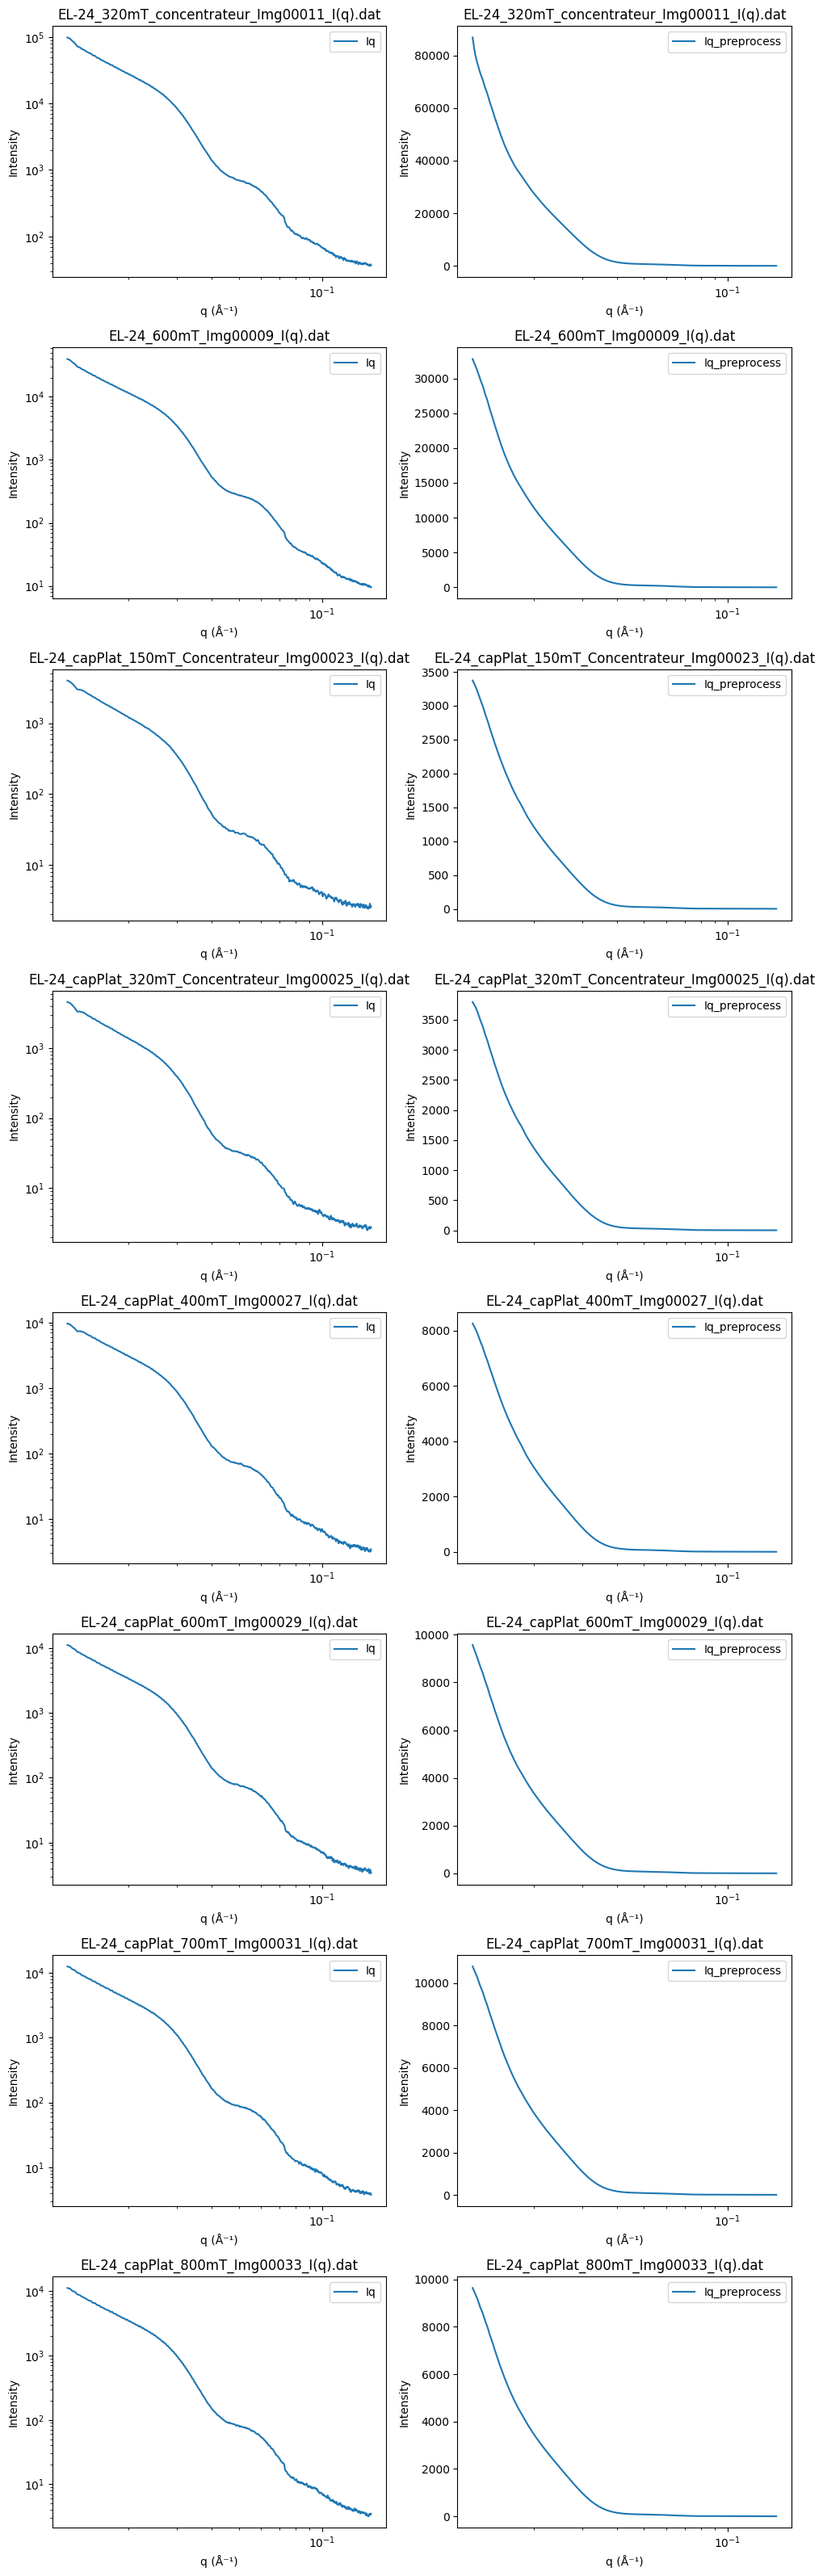

In [3]:

fenetre= (0.012, 0.15)
(batch
.preprocess
.savgol(window=40)
# .savgol()
.up_scale()
.feat_power_law(average=False, bounds=fenetre, verbose=True) # mettre average a false si on veut calculer la power law pour chaque echantillon
)
batch.apply_masks(*fenetre)

batch.plot( subplot=True, curves=(['Iq'], ['Iq_preprocess']), peaks=True, plot_type=('loglog', 'semilogx'), legend=(True, True))


In [4]:
'''(batch
.findpeaks

.asym2sig(n_expected_peaks=2)
.standard(n_expected_peaks=2)
.spv(n_expected_peaks=2)
.spv_off(n_expected_peaks=2)
)'''

(batch
.findpeaks
.standard()
.spv()
.spv_off()
.asym2sig()
)

batch.plot( subplot=True, curves=(['Iq'], ['Iq_preprocess']), peaks=True, plot_type=('loglog', 'semilogx'), legend=(True, False))


RuntimeError: [File:EL-24_600mT_Img00009_I(q).dat] No peaks detected during standard peak search.

In [ ]:

import pandas as pd
import numpy as np

Imax = batch.analyse.IMax()

rows = []

for key, exp in batch.experiments.items():
    name = exp.name

    # --- Sécurité sur infos ---
    infos = getattr(exp.Iq_preprocess, "infos", {})
    Imin_val = exp.metadata['Intensity_min'] 
    order_bg = exp.metadata['power_law_order'] 

    Imax_list = Imax.get(key, None)

    # Debug optionnel
    print(name, "Imin =", Imin_val, "Imax =", Imax_list)

    # --- Conditions minimales ---
    if Imin_val is None or Imax_list is None:
        print(f"[SKIP] {name} → Imin or Imax missing")
        continue

    # --- Calcul intensités normalisées ---
    ratios = [
        float(Imax_list[i] - Imin_val)
        for i in range(len(Imax_list))
    ]

    # --- Pics ---
    if "Standard" not in exp.peaks:
        print(f"[SKIP] {name} → no Standard peaks")
        continue

    q_peaks = exp.peaks["Standard"].get("q_values", [])

    if len(q_peaks) == 0:
        print(f"[SKIP] {name} → no peaks detected")
        continue

    # --- Ligne Excel ---
    row = {
        "fenetre": fenetre,
        "Nom fichier": name,

        "q Pic 1": q_peaks[0],
        "q Pic 2": q_peaks[1] if len(q_peaks) > 1 else None,
        "q Pic 3": q_peaks[2] if len(q_peaks) > 2 else None,

        "Pic 2 / Pic 1": q_peaks[1] / q_peaks[0] if len(q_peaks) > 1 else None,
        "Pic 3 / Pic 1": q_peaks[2] / q_peaks[0] if len(q_peaks) > 2 else None,

        "I Pic 1": ratios[0],
        "I Pic 2": ratios[1] if len(ratios) > 1 else None,
        "I Pic 3": ratios[2] if len(ratios) > 2 else None,

        "ordre background": order_bg,
        "distance (nm)": 2 * np.pi / (q_peaks[0] * 10)
    }

    rows.append(row)

# --- DataFrame final ---
df = pd.DataFrame(rows)
df

EL-24_320mT_concentrateur_I(q)_az=-89°_fullwidth=10.0.dat Imin = 0.034305879293653835 Imax = [0.11820036092967752, 0.06817866592894395, 0.04487853847730141]
EL-24_600mT_I(q)_az=-89°_fullwidth=10.0.dat Imin = 0.013842430322404654 Imax = [0.05228705383107152, 0.029797576647503522, 0.018547345429285746]
EL-24_capPlat_150mT_Concentrateur_I(q)_az=-89°_fullwidth=10.0.dat Imin = 0.0017302445570329162 Imax = [0.0073818799055811735, 0.0037459440012460334, 0.0035130275288974026]
EL-24_capPlat_320mT_Concentrateur_I(q)_az=-89°_fullwidth=10.0.dat Imin = 0.0012643128462889537 Imax = [0.004844881803719892, 0.0029408283952760054, 0.0019792824817055055]
EL-24_capPlat_400mT_I(q)_az=-88°_fullwidth=10.0.dat Imin = 0.0029721152286641696 Imax = [0.010474370390636707, 0.006036726369523231, 0.0039233330475636095]
EL-24_capPlat_400mT_I(q)_az=-89°_fullwidth=10.0.dat Imin = 0.0029721011185524465 Imax = [0.01056567911695736, 0.006150422189414768, 0.0038427051513482695]
EL-24_capPlat_600mT_I(q)_az=-89°_fullwidth=1

,fenetre,Nom fichier,q Pic 1,q Pic 2,q Pic 3,Pic 2 / Pic 1,Pic 3 / Pic 1,I Pic 1,I Pic 2,I Pic 3,ordre background,distance (nm)
0,"(0.012, 0.15)",EL-24_320mT_concentrateur_I(q)_az=-89°_fullwid...,0.027896,0.061153,0.098593,2.192177,3.534301,0.083894,0.033873,0.010573,3.677601,22.523520
1,"(0.012, 0.15)",EL-24_600mT_I(q)_az=-89°_fullwidth=10.0.dat,0.027793,0.060637,0.097819,2.181742,3.519564,0.038445,0.015955,0.004705,3.642265,22.607221
2,"(0.012, 0.15)",EL-24_capPlat_150mT_Concentrateur_I(q)_az=-89°...,0.026760,0.058674,0.138770,2.192617,5.185737,0.005652,0.002016,0.001783,3.458830,23.479769
3,"(0.012, 0.15)",EL-24_capPlat_320mT_Concentrateur_I(q)_az=-89°...,0.026863,0.059811,0.095495,2.226479,3.554844,0.003581,0.001677,0.000715,3.688542,23.389495
4,"(0.012, 0.15)",EL-24_capPlat_400mT_I(q)_az=-88°_fullwidth=10....,0.026760,0.058829,0.098542,2.198406,3.682422,0.007502,0.003065,0.000951,3.689502,23.479769
5,"(0.012, 0.15)",EL-24_capPlat_400mT_I(q)_az=-89°_fullwidth=10....,0.026760,0.058623,0.098542,2.190687,3.682422,0.007594,0.003178,0.000871,3.683509,23.479769
6,"(0.012, 0.15)",EL-24_capPlat_600mT_I(q)_az=-89°_fullwidth=10....,0.026863,0.059397,0.094204,2.211100,3.506784,0.010194,0.004179,0.001116,3.667960,23.389495
7,"(0.012, 0.15)",EL-24_capPlat_700mT_I(q)_az=-89°_fullwidth=10....,0.026812,0.060327,0.098387,2.250028,3.669552,0.012173,0.005436,0.001613,3.688513,23.434545
8,"(0.012, 0.15)",EL-24_capPlat_800mT_I(q)_az=-88°_fullwidth=10....,0.026915,0.059759,0.094307,2.220288,3.503893,0.011860,0.005485,0.001583,3.710880,23.344618


Analyse pour differentes méthodes : 

In [ ]:
import pandas as pd
import numpy as np

Imin = batch.analyse.IMin()
Imax = batch.analyse.IMax()

rows = []

METHODS = ["Standard", "Asym2Sig", "SPV", "SPV_off"]

for key, exp in batch.experiments.items():

    name = exp.name
    Imin_val = Imin.get(key)
    Imax_list = Imax.get(key)

    if Imin_val is None or Imax_list is None:
        continue

    # Calcul des intensités normalisées
    ratios = [float(Imax_list[i] / Imin_val) for i in range(len(Imax_list))]

    for method in METHODS:

        if method not in exp.peaks:
            continue

        qvals = exp.peaks[method].get("q_values", [])

        if len(qvals) == 0:
            continue

        row = {
            "Nom fichier": name,
            "Méthode": method,

            # q-values
            "Pic 1 (q)": qvals[0],
            "Pic 2 (q)": qvals[1] if len(qvals) > 1 else None,
            "Pic 3 (q)": qvals[2] if len(qvals) > 2 else None,

            # ratios q
            "Pic2/Pic1": qvals[1] / qvals[0] if len(qvals) > 1 else None,
            "Pic3/Pic1": qvals[2] / qvals[0] if len(qvals) > 2 else None,

            # distance
            "Distance (nm)": 2 * np.pi / (qvals[0] * 10),

            "I Pic 1": ratios[0],
            "I Pic 2": ratios[1] if len(ratios) > 1 else None,
            "I Pic 3": ratios[2] if len(ratios) > 2 else None,
        }

        rows.append(row)

# Construction du tableau
df = pd.DataFrame(rows)
df


,Nom fichier,Méthode,Pic 1 (q),Pic 2 (q),Pic 3 (q),Pic2/Pic1,Pic3/Pic1,Distance (nm),I Pic 1,I Pic 2,I Pic 3
0,EL-24_320mT_concentrateur_I(q)_az=-89°_fullwid...,Standard,0.027896,0.061102,0.098593,2.190326,3.534301,22.523520,3.459821,1.981360,1.298534
1,EL-24_320mT_concentrateur_I(q)_az=-89°_fullwid...,Asym2Sig,0.028051,0.060740,0.098593,2.165342,3.514782,22.399124,3.459821,1.981360,1.298534
2,EL-24_320mT_concentrateur_I(q)_az=-89°_fullwid...,SPV,0.027948,0.060688,0.098697,2.171496,3.531466,22.481901,3.459821,1.981360,1.298534
3,EL-24_320mT_concentrateur_I(q)_az=-89°_fullwid...,SPV_off,0.027896,0.060585,0.098025,2.171814,3.513938,22.523520,3.459821,1.981360,1.298534
4,EL-24_600mT_I(q)_az=-89°_fullwidth=10.0.dat,Standard,0.027896,0.060688,0.097870,2.175516,3.508384,22.523520,3.666767,2.201752,1.415194
5,EL-24_600mT_I(q)_az=-89°_fullwidth=10.0.dat,Asym2Sig,0.027896,0.060585,0.098335,2.171814,3.525045,22.523520,3.666767,2.201752,1.415194
6,EL-24_600mT_I(q)_az=-89°_fullwidth=10.0.dat,SPV,0.027844,0.060792,0.097509,2.183260,3.501909,22.565293,3.666767,2.201752,1.415194
7,EL-24_600mT_I(q)_az=-89°_fullwidth=10.0.dat,SPV_off,0.027896,0.060740,0.097870,2.177367,3.508384,22.523520,3.666767,2.201752,1.415194
8,EL-24_capPlat_0mT_I(q)_az=-89°_fullwidth=10.0.dat,Standard,0.026192,0.121729,0.135414,4.647560,5.170049,23.989003,-88.029517,-110.308902,-127.938873
9,EL-24_capPlat_0mT_I(q)_az=-89°_fullwidth=10.0.dat,Asym2Sig,0.025830,0.136292,NaN,5.276389,NaN,24.324723,-88.029517,-110.308902,-127.938873


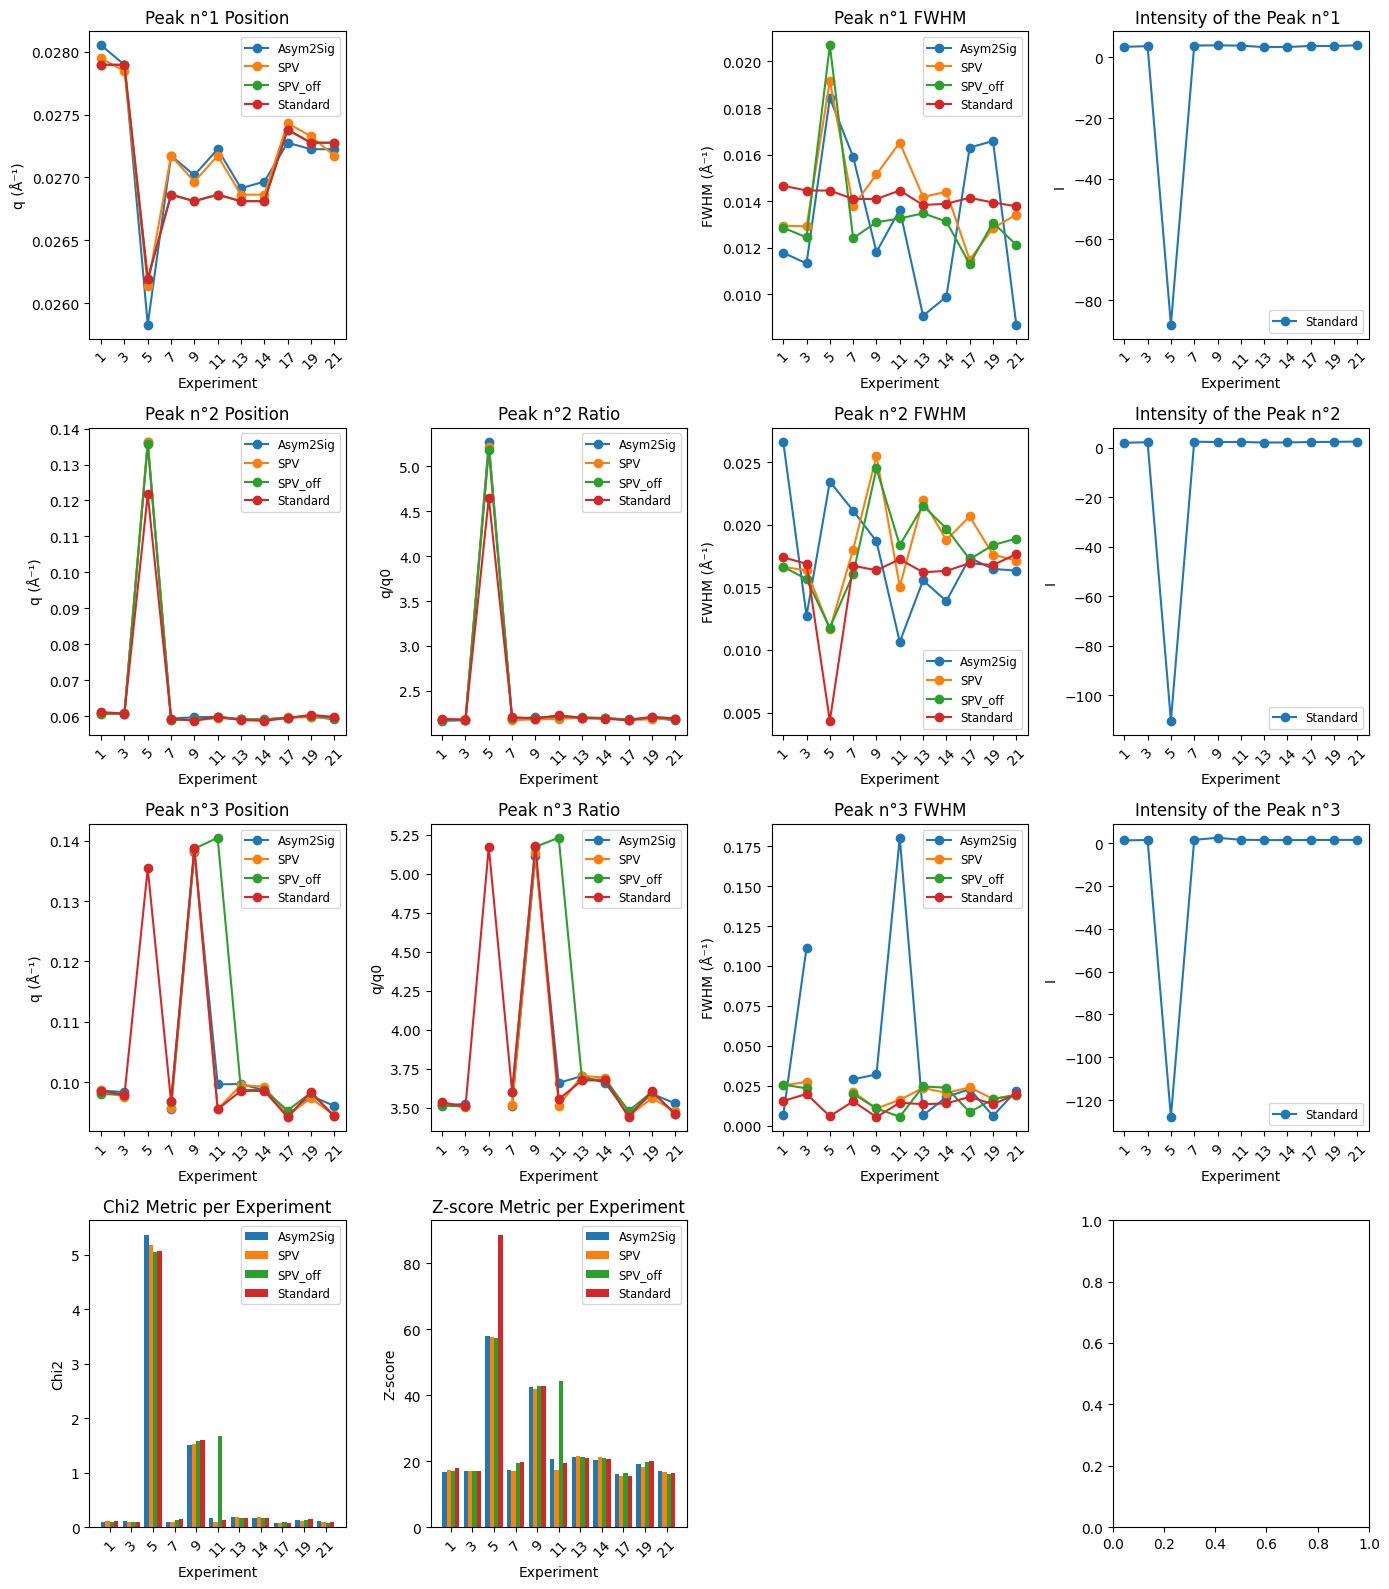

In [ ]:
(batch
 .analyse
 .overview()
)

In [ ]:
Imin =batch.analyse.IMin()
Imax = batch.analyse.IMax()

Imax_val = [0,0,0]

for key in Imin:
    if key in Imax:
        Imin_val = Imin[key]
        for i in range(len(Imax[key])):
            Imax_val[i] = float(Imax[key][i] / Imin_val)
        print(f"L'intensité des pics pour l'exp {key} est {Imax_val}")




L'intensité des pics pour l'exp 1 est [3.459821399252311, 1.9813595129148454, 1.2985341681858777]
L'intensité des pics pour l'exp 3 est [3.6667669797352076, 2.2017515376417913, 1.415193581877521]
L'intensité des pics pour l'exp 5 est [-88.02951719370272, -110.30890174461912, -127.93887252418601]
L'intensité des pics pour l'exp 7 est [3.8767767012214978, 2.408465478312823, 1.509771224487918]
L'intensité des pics pour l'exp 9 est [3.9426337038806105, 2.283539968164826, 2.476034750800266]
L'intensité des pics pour l'exp 11 est [3.839438807925373, 2.3225616410951306, 1.5600413711533057]
L'intensité des pics pour l'exp 13 est [3.3582912856338614, 2.0799633810168046, 1.4170995932481107]
L'intensité des pics pour l'exp 14 est [3.3969632373447527, 2.1157945191170637, 1.3824684951812516]
L'intensité des pics pour l'exp 17 est [3.7389703549883104, 2.2816117632072777, 1.4406534651781784]
L'intensité des pics pour l'exp 19 est [3.718426897954394, 2.3531060136616704, 1.4861033858384545]
L'intensité

In [ ]:
for key, exp in batch.experiments.items():
    q_peaks = exp.peaks['Standard']['q_values']
    print(f"Methode standart : {exp.name}: {len(q_peaks)} pics trouvés à q = {', '.join(f'{q:.4f}' for q in q_peaks)}")
    q_peaks = exp.peaks['Asym2Sig']['q_values']
    print(f"Methode Asym2Sig : {exp.name}: {len(q_peaks)} pics trouvés à q = {', '.join(f'{q:.4f}' for q in q_peaks)}")
    q_peaks = exp.peaks['SPV']['q_values']
    print(f"Methode SPV : {exp.name}: {len(q_peaks)} pics trouvés à q = {', '.join(f'{q:.4f}' for q in q_peaks)}")
    q_peaks = exp.peaks['SPV_off']['q_values']
    print(f"Methode fSPV off : {exp.name}: {len(q_peaks)} pics trouvés à q = {', '.join(f'{q:.4f}' for q in q_peaks)}")
    

Methode standart : EL-24_320mT_concentrateur_I(q)_az=-89°_fullwidth=10.0.dat: 3 pics trouvés à q = 0.0279, 0.0611, 0.0986
Methode Asym2Sig : EL-24_320mT_concentrateur_I(q)_az=-89°_fullwidth=10.0.dat: 3 pics trouvés à q = 0.0281, 0.0607, 0.0986
Methode SPV : EL-24_320mT_concentrateur_I(q)_az=-89°_fullwidth=10.0.dat: 3 pics trouvés à q = 0.0279, 0.0607, 0.0987
Methode fSPV off : EL-24_320mT_concentrateur_I(q)_az=-89°_fullwidth=10.0.dat: 3 pics trouvés à q = 0.0279, 0.0606, 0.0980
Methode standart : EL-24_600mT_I(q)_az=-89°_fullwidth=10.0.dat: 3 pics trouvés à q = 0.0279, 0.0607, 0.0979
Methode Asym2Sig : EL-24_600mT_I(q)_az=-89°_fullwidth=10.0.dat: 3 pics trouvés à q = 0.0279, 0.0606, 0.0983
Methode SPV : EL-24_600mT_I(q)_az=-89°_fullwidth=10.0.dat: 3 pics trouvés à q = 0.0278, 0.0608, 0.0975
Methode fSPV off : EL-24_600mT_I(q)_az=-89°_fullwidth=10.0.dat: 3 pics trouvés à q = 0.0279, 0.0607, 0.0979
Methode standart : EL-24_capPlat_0mT_I(q)_az=-89°_fullwidth=10.0.dat: 3 pics trouvés à q =

In [ ]:
exp = list(batch.experiments.values())[0]
print(" ce qu'il y a dans exp")
print(dir(exp))
print(" Type ?")
print(type(exp.Iq_preprocess))
print(" ce qu'il y a dans I preprocess")
print(dir(exp.Iq_preprocess))


 ce qu'il y a dans exp
['Asym2Sig_residuals', 'Asym2Sig_theory', 'Iq', 'Iq_peakfinder', 'Iq_preprocess', 'SPV_off_residuals', 'SPV_off_theory', 'SPV_residuals', 'SPV_theory', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__firstlineno__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', 'add_data', 'apply_masks', 'cancel_power_law', 'copy', 'feat_power_law', 'find_peaks_asym2sig', 'find_peaks_asym2sig_batch', 'find_peaks_spv', 'find_peaks_spv_batch', 'find_peaks_spv_off', 'find_peaks_spv_off_batch', 'find_peaks_standard', 'gaussian', 'metadata', 'moving_average', 'name', 'normalize', 'peaks', 'plot', 'savgol', 'up_scale']
 Type ?


TypeError: 'str' object is not callable

In [ ]:
for key, exp in batch.experiments.items():
    print(dir(exp.Iq_preprocess.get_raw_data))
    print(dir(exp.peaks))
    #print(dir(exp.peaks.Standard.q_values))

    
    
   

In [ ]:
exp = next(iter(batch.experiments.values()))
exp.__dict__.keys()

In [ ]:
data = exp.Iq_preprocess
type(data)
data.__dict__.keys()

In [ ]:
x, y, dy = exp.Iq_preprocess.get_filtered_data()
q_peaks = exp.peaks['Asym2Sig']['q_values']

In [ ]:
indices = [np.argmin(np.abs(x - qpk)) for qpk in q_peaks]
I_peaks = [y[i] for i in indices]

print(I_peaks)

In [ ]:
I_peak_data = {}   # dictionnaire final : {exp_name: {method: [I_peaks] } }

for key, exp in batch.experiments.items():

    # Récupération des données filtrées
    x, y, dy = exp.Iq_preprocess.get_filtered_data()

    I_peak_data[key] = {}

    # Pour chaque méthode : Standard, Asym2Sig, SPV, SPV_off…
    for method in exp.peaks.names():

        q_peaks = exp.peaks[method].get('q_values', None)
        if q_peaks is None:
            continue

        # Trouver I(q_peak)
        indices = [np.argmin(np.abs(x - qpk)) for qpk in q_peaks]
        I_peaks = [float(y[i]) for i in indices]   # float() pour sérialiser proprement

        I_peak_data[key][method] = I_peaks

# Vérifions un exemple
from pprint import pprint
pprint(I_peak_data)